# Pipeline: СЃСЂР°РІРЅРµРЅРёРµ KMeans, GMM Рё HDBSCAN РґР»СЏ РІС‹РґРµР»РµРЅРёСЏ СЌРЅРµСЂРіРѕС‘РјРєРѕСЃС‚Рё РїРѕСЂРѕРґ

Р¦РµР»СЊ: РІС‹РґРµР»РёС‚СЊ **energy-response / hardness regimes**, Р° РЅРµ РїСЂРѕСЃС‚Рѕ СЂРµР¶РёРјС‹ СЂР°Р±РѕС‚С‹ РѕРїРµСЂР°С‚РѕСЂРѕРІ.

Pipeline:

1. Р—Р°РіСЂСѓР¶Р°РµРј РґР°РЅРЅС‹Рµ.
2. РЎС‚СЂРѕРёРј proxy energy features:
   - `energy_proxy`
   - `pseudo_mse`
   - `drilling_efficiency`
   - `rotation_efficiency`
3. РЎС‚СЂРѕРёРј residual hardness:
   - `expected_speed_from_controls`
   - `formation_residual`
4. РЎРіР»Р°Р¶РёРІР°РµРј РїСЂРёР·РЅР°РєРё РІРѕ РІСЂРµРјРµРЅРё.
5. РЎРѕР·РґР°С‘Рј continuous `hardness_score`.
6. РЎСЂР°РІРЅРёРІР°РµРј:
   - KMeans
   - Gaussian Mixture Model
   - HDBSCAN
7. РРЅС‚РµСЂРїСЂРµС‚РёСЂСѓРµРј РєР»Р°СЃС‚РµСЂС‹ Рё РїСЂРѕРІРµСЂСЏРµРј, РЅРµ РІС‹РґРµР»РёР»Рё Р»Рё РјС‹ РїСЂРѕСЃС‚Рѕ СѓРїСЂР°РІР»РµРЅРёРµ.
8. РЎРѕС…СЂР°РЅСЏРµРј РґР°С‚Р°СЃРµС‚ СЃ РІС‹Р±СЂР°РЅРЅС‹РјРё labels.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import subprocess
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

RANDOM_STATE = 42
EPS = 1e-6

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. РЈСЃС‚Р°РЅРѕРІРєР° / РёРјРїРѕСЂС‚ HDBSCAN

Р•СЃР»Рё РїР°РєРµС‚ `hdbscan` РЅРµ СѓСЃС‚Р°РЅРѕРІР»РµРЅ, СЏС‡РµР№РєР° РїРѕРїСЂРѕР±СѓРµС‚ СѓСЃС‚Р°РЅРѕРІРёС‚СЊ РµРіРѕ Р°РІС‚РѕРјР°С‚РёС‡РµСЃРєРё.

Р•СЃР»Рё СЃСЂРµРґР° Р±РµР· РёРЅС‚РµСЂРЅРµС‚Р° вЂ” РјРѕР¶РЅРѕ РїСЂРѕРїСѓСЃС‚РёС‚СЊ HDBSCAN Рё СЃСЂР°РІРЅРёС‚СЊ С‚РѕР»СЊРєРѕ KMeans/GMM.

In [2]:
def ensure_hdbscan():
    if importlib.util.find_spec("hdbscan") is None:
        print("hdbscan РЅРµ РЅР°Р№РґРµРЅ. РџСЂРѕР±СѓСЋ СѓСЃС‚Р°РЅРѕРІРёС‚СЊ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "hdbscan"])
        except Exception as e:
            print("РќРµ СѓРґР°Р»РѕСЃСЊ СѓСЃС‚Р°РЅРѕРІРёС‚СЊ hdbscan:", repr(e))
            return None

    try:
        import hdbscan
        return hdbscan
    except Exception as e:
        print("РќРµ СѓРґР°Р»РѕСЃСЊ РёРјРїРѕСЂС‚РёСЂРѕРІР°С‚СЊ hdbscan:", repr(e))
        return None

hdbscan = ensure_hdbscan()
print("hdbscan available:", hdbscan is not None)

hdbscan available: True


## 2. Р—Р°РіСЂСѓР·РєР° РґР°РЅРЅС‹С…

In [5]:
DATA_PATH = "../datasets/united.csv"

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["processing_time"] = pd.to_datetime(df["processing_time"])
df = df.sort_values(["well_id", "processing_time"]).reset_index(drop=True)

print(df.shape)
df.head()

(415049, 6)


,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed
0,2025-08-24 10:09:50.980,74.256,804,4551,19601,0.002755
1,2025-08-24 10:10:00.260,73.812,763,3782,19601,0.003030
2,2025-08-24 10:10:05.199,73.512,879,4407,19601,0.006060
3,2025-08-24 10:10:14.610,73.962,721,3705,19601,0.002755
4,2025-08-24 10:10:34.197,74.256,859,3883,19601,0.001515


## 3. Р‘Р°Р·РѕРІР°СЏ РѕС‡РёСЃС‚РєР°

In [6]:
required_cols = [
    "processing_time",
    "well_id",
    "rotation",
    "pressure_axis",
    "pressure_rotation",
    "speed",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"РќРµ С…РІР°С‚Р°РµС‚ РєРѕР»РѕРЅРѕРє: {missing}")

print("Missing values:")
display(df[required_cols].isna().sum())

before = len(df)

df = df[
    (df["speed"] > 0) &
    (df["rotation"] > 0) &
    (df["pressure_axis"] > 0) &
    (df["pressure_rotation"] > 0)
].copy()

after = len(df)
print(f"Rows before={before:,}, after={after:,}, removed={before-after:,}")

df.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

Missing values:


processing_time      0
well_id              0
rotation             0
pressure_axis        0
pressure_rotation    0
speed                0
dtype: int64

Rows before=415,049, after=415,049, removed=0


,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed
count,415049,415049.000000,415049.000000,415049.000000,415049.000000,415049.000000
mean,2025-09-30 16:29:50.410853,103.945315,17473.667273,14134.146325,24734.204520,0.013116
min,2025-08-24 10:09:50.980000,50.010000,317.000000,784.000000,19601.000000,0.001002
1%,2025-08-24 22:59:37.225600,64.980000,3713.000000,6271.000000,19667.000000,0.002755
5%,2025-08-27 22:17:24.985400,81.750000,6645.000000,8246.000000,20072.000000,0.005050
50%,2025-09-26 04:46:36.308000,103.158000,18861.000000,14637.000000,23921.000000,0.012120
95%,2025-11-08 03:44:56.550400,138.474000,22343.000000,18758.600000,31073.000000,0.024240
99%,2025-11-11 00:26:54.295320,139.020000,23626.000000,20881.000000,31795.000000,0.030300
max,2025-11-11 16:51:54.763000,139.578000,24872.000000,26318.000000,31958.000000,0.038957
std,NaN,13.370361,4682.982816,3243.523440,3461.705706,0.006615


## 4. Р’СЂРµРјРµРЅРЅРѕР№ С€Р°Рі

In [7]:
df["dt"] = (
    df.groupby("well_id")["processing_time"]
      .diff()
      .dt.total_seconds()
)

df["dt"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    413343.000000
mean          7.279416
std         110.620952
min           0.089000
1%            0.229000
5%            0.463100
50%           5.135000
95%          10.897000
99%          23.771320
max       42583.603000
Name: dt, dtype: float64

## 5. Energy-response РїСЂРёР·РЅР°РєРё

РќРµ РёСЃРїРѕР»СЊР·СѓРµРј raw-СЃРёРіРЅР°Р»С‹ РЅР°РїСЂСЏРјСѓСЋ РєР°Рє proxy РїРѕСЂРѕРґС‹.  
РЎРЅР°С‡Р°Р»Р° РїРµСЂРµРІРѕРґРёРј РёС… РІ РїСЂРѕСЃС‚СЂР°РЅСЃС‚РІРѕ "СЌРЅРµСЂРіРёСЏ в†’ РѕС‚РєР»РёРє".

In [8]:
df["energy_proxy"] = (
    df["pressure_axis"] +
    df["pressure_rotation"] * df["rotation"]
)

df["pseudo_mse"] = df["energy_proxy"] / (df["speed"] + EPS)

df["drilling_efficiency"] = df["speed"] / (df["energy_proxy"] + EPS)

df["rotation_efficiency"] = df["rotation"] / (df["pressure_rotation"] + EPS)

df["pressure_balance"] = (
    df["pressure_axis"] /
    (df["pressure_axis"] + df["pressure_rotation"] + EPS)
)

df[[
    "energy_proxy",
    "pseudo_mse",
    "drilling_efficiency",
    "rotation_efficiency",
    "pressure_balance",
]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,energy_proxy,pseudo_mse,drilling_efficiency,rotation_efficiency,pressure_balance
count,4.150490e+05,4.150490e+05,4.150490e+05,415049.000000,415049.000000
mean,1.494500e+06,1.467727e+08,9.279041e-09,0.007803,0.545942
std,4.009753e+05,9.155477e+07,5.931875e-09,0.002483,0.057506
min,4.174649e+04,3.009300e+06,3.870720e-10,0.002104,0.013293
1%,4.697380e+05,3.257078e+07,2.153750e-09,0.004789,0.320485
5%,7.635049e+05,5.221720e+07,3.292781e-09,0.005407,0.428681
50%,1.542361e+06,1.239899e+08,8.064516e-09,0.007111,0.558077
95%,2.119089e+06,3.036335e+08,1.914947e-08,0.012153,0.607300
99%,2.462635e+06,4.641533e+08,3.070111e-08,0.015835,0.629086
max,3.668551e+06,2.581497e+09,3.322895e-07,0.121481,0.933514


## 6. РЎРіР»Р°Р¶РёРІР°РЅРёРµ

Р”Р»СЏ offline-СЂР°Р·РјРµС‚РєРё СЌРЅРµСЂРіРѕС‘РјРєРѕСЃС‚Рё РёСЃРїРѕР»СЊР·СѓРµРј rolling statistics Р±РµР· `shift(1)`, РїРѕС‚РѕРјСѓ С‡С‚Рѕ РјС‹ РѕРїРёСЃС‹РІР°РµРј СѓР¶Рµ РЅР°Р±Р»СЋРґР°РІС€РёР№СЃСЏ РёРЅС‚РµСЂРІР°Р».

Р”Р»СЏ online-РІРµСЂСЃРёРё РЅСѓР¶РЅРѕ Р·Р°РјРµРЅРёС‚СЊ РЅР° `shift(1).rolling(...)`.

In [9]:
def add_rolling_stats(data, cols, windows=(12, 30, 60), group_col="well_id"):
    out = data.copy()

    for col in cols:
        for w in windows:
            min_p = max(3, w // 3)

            out[f"{col}_roll_median_{w}"] = (
                out.groupby(group_col)[col]
                   .transform(lambda s: s.rolling(w, min_periods=min_p).median())
            )

            out[f"{col}_roll_mean_{w}"] = (
                out.groupby(group_col)[col]
                   .transform(lambda s: s.rolling(w, min_periods=min_p).mean())
            )

            out[f"{col}_roll_std_{w}"] = (
                out.groupby(group_col)[col]
                   .transform(lambda s: s.rolling(w, min_periods=min_p).std())
            )

    return out


formation_cols = [
    "pseudo_mse",
    "drilling_efficiency",
    "rotation_efficiency",
    "energy_proxy",
    "speed",
    "rotation",
    "pressure_balance",
]

df = add_rolling_stats(df, formation_cols, windows=(12, 30, 60))

df.head()

,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed,dt,energy_proxy,pseudo_mse,drilling_efficiency,rotation_efficiency,pressure_balance,pseudo_mse_roll_median_12,pseudo_mse_roll_mean_12,pseudo_mse_roll_std_12,pseudo_mse_roll_median_30,pseudo_mse_roll_mean_30,pseudo_mse_roll_std_30,pseudo_mse_roll_median_60,pseudo_mse_roll_mean_60,pseudo_mse_roll_std_60,drilling_efficiency_roll_median_12,drilling_efficiency_roll_mean_12,drilling_efficiency_roll_std_12,drilling_efficiency_roll_median_30,drilling_efficiency_roll_mean_30,drilling_efficiency_roll_std_30,drilling_efficiency_roll_median_60,drilling_efficiency_roll_mean_60,drilling_efficiency_roll_std_60,rotation_efficiency_roll_median_12,rotation_efficiency_roll_mean_12,rotation_efficiency_roll_std_12,rotation_efficiency_roll_median_30,rotation_efficiency_roll_mean_30,rotation_efficiency_roll_std_30,rotation_efficiency_roll_median_60,rotation_efficiency_roll_mean_60,rotation_efficiency_roll_std_60,energy_proxy_roll_median_12,energy_proxy_roll_mean_12,energy_proxy_roll_std_12,energy_proxy_roll_median_30,energy_proxy_roll_mean_30,energy_proxy_roll_std_30,energy_proxy_roll_median_60,energy_proxy_roll_mean_60,energy_proxy_roll_std_60,speed_roll_median_12,speed_roll_mean_12,speed_roll_std_12,speed_roll_median_30,speed_roll_mean_30,speed_roll_std_30,speed_roll_median_60,speed_roll_mean_60,speed_roll_std_60,rotation_roll_median_12,rotation_roll_mean_12,rotation_roll_std_12,rotation_roll_median_30,rotation_roll_mean_30,rotation_roll_std_30,rotation_roll_median_60,rotation_roll_mean_60,rotation_roll_std_60,pressure_balance_roll_median_12,pressure_balance_roll_mean_12,pressure_balance_roll_std_12,pressure_balance_roll_median_30,pressure_balance_roll_mean_30,pressure_balance_roll_std_30,pressure_balance_roll_median_60,pressure_balance_roll_mean_60,pressure_balance_roll_std_60
0,2025-08-24 10:09:50.980,74.256,804,4551,19601,0.002755,NaN,338743.056,1.229314e+08,8.131666e-09,0.016316,0.150140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-24 10:10:00.260,73.812,763,3782,19601,0.003030,9.280,279919.984,9.235235e+07,1.082452e-08,0.019517,0.167877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-24 10:10:05.199,73.512,879,4407,19601,0.006060,4.939,324846.384,5.359617e+07,1.865497e-08,0.016681,0.166288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-24 10:10:14.610,73.962,721,3705,19601,0.002755,9.411,274750.210,9.970810e+07,1.002564e-08,0.019963,0.162901,9.603023e+07,9.214701e+07,2.881584e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.042508e-08,1.190920e-08,4.636793e-09,NaN,NaN,NaN,NaN,NaN,NaN,0.018099,0.018119,0.001886,NaN,NaN,NaN,NaN,NaN,NaN,302383.184,304564.9085,32019.642749,NaN,NaN,NaN,NaN,NaN,NaN,0.002892,0.003650,0.001612,NaN,NaN,NaN,NaN,NaN,NaN,73.887,73.8855,0.309853,NaN,NaN,NaN,NaN,NaN,NaN,0.164595,0.161802,0.008047,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-24 10:10:34.197,74.256,859,3883,19601,0.001515,19.587,289195.048,1.907619e+08,5.238679e-09,0.019123,0.181147,9.970810e+07,1.118700e+08,5.067291e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.002564e-08,1.057509e-08,5.002404e-09,NaN,NaN,NaN,NaN,NaN,NaN,0.019123,0.018320,0.001694,NaN,NaN,NaN,NaN,NaN,NaN,289195.048,301490.9364,28569.033300,NaN,NaN,NaN,NaN,NaN,NaN,0.002755,0.003223,0.001691,NaN,NaN,NaN,NaN,NaN,NaN,73.962,73.9596,0.315374,NaN,NaN,NaN,NaN,NaN,NaN,0.166288,0.165671,0.011109,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Residual hardness: РѕС‚РґРµР»СЏРµРј РІР»РёСЏРЅРёРµ СѓРїСЂР°РІР»РµРЅРёСЏ

РњРѕРґРµР»СЊ РѕР±СЉСЏСЃРЅСЏРµС‚ `speed` С‡РµСЂРµР· СѓРїСЂР°РІР»РµРЅРёРµ Рё РјРµС…Р°РЅРёС‡РµСЃРєРёР№ РѕС‚РєР»РёРє.

Р—Р°С‚РµРј:

`formation_residual = actual_speed - expected_speed_from_controls`

- residual > 0: Р±СѓСЂРёС‚СЃСЏ Р»РµРіС‡Рµ, С‡РµРј РѕР¶РёРґР°Р»РѕСЃСЊ;
- residual < 0: Р±СѓСЂРёС‚СЃСЏ С‚СЏР¶РµР»РµРµ, С‡РµРј РѕР¶РёРґР°Р»РѕСЃСЊ.

In [10]:
control_features = [
    "pressure_axis",
    "pressure_rotation",
    "rotation",
    "pressure_balance",
    "rotation_efficiency",
    "energy_proxy",
]

control_df = df.dropna(subset=control_features + ["speed", "well_id"]).copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(control_df, groups=control_df["well_id"]))

train_control = control_df.iloc[train_idx].copy()
test_control = control_df.iloc[test_idx].copy()

speed_baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=RANDOM_STATE
    ))
])

speed_baseline_model.fit(train_control[control_features], train_control["speed"])

pred_test = speed_baseline_model.predict(test_control[control_features])

mae = mean_absolute_error(test_control["speed"], pred_test)
rmse = root_mean_squared_error(test_control["speed"], pred_test)
r2 = r2_score(test_control["speed"], pred_test)

print(f"Control baseline model | MAE={mae:.6f} | RMSE={rmse:.6f} | R2={r2:.4f}")

Control baseline model | MAE=0.004748 | RMSE=0.006027 | R2=0.1729


## 8. Residual-РїСЂРёР·РЅР°РєРё

In [11]:
df["expected_speed_from_controls"] = speed_baseline_model.predict(df[control_features])

df["formation_residual"] = df["speed"] - df["expected_speed_from_controls"]

df["relative_formation_residual"] = (
    df["formation_residual"] /
    (np.abs(df["expected_speed_from_controls"]) + EPS)
)

df = add_rolling_stats(
    df,
    cols=["formation_residual", "relative_formation_residual"],
    windows=(12, 30, 60)
)

df[[
    "speed",
    "expected_speed_from_controls",
    "formation_residual",
    "relative_formation_residual",
]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,speed,expected_speed_from_controls,formation_residual,relative_formation_residual
count,415049.000000,415049.000000,4.150490e+05,415049.000000
mean,0.013116,0.013116,1.438309e-07,-0.005611
std,0.006615,0.002603,5.960129e-03,0.459752
min,0.001002,0.005248,-1.707994e-02,-0.936293
1%,0.002755,0.006537,-1.083184e-02,-0.777171
5%,0.005050,0.008087,-8.661932e-03,-0.618444
50%,0.012120,0.013426,-7.614439e-04,-0.062225
95%,0.024240,0.016946,1.057456e-02,0.810934
99%,0.030300,0.017626,1.766537e-02,1.344340
max,0.038957,0.018410,3.058625e-02,5.296554


## 9. Continuous hardness score

РљР»Р°СЃС‚РµСЂС‹ РїРѕР»РµР·РЅС‹, РЅРѕ СЌРЅРµСЂРіРѕС‘РјРєРѕСЃС‚СЊ С‡Р°СЃС‚Рѕ СЏРІР»СЏРµС‚СЃСЏ РЅРµРїСЂРµСЂС‹РІРЅРѕР№.  
РџРѕСЌС‚РѕРјСѓ РґРѕР±Р°РІР»СЏРµРј `hardness_score`, С‡С‚РѕР±С‹ РЅРµ Р·Р°РІРёСЃРµС‚СЊ С‚РѕР»СЊРєРѕ РѕС‚ РґРёСЃРєСЂРµС‚РЅРѕР№ СЂР°Р·РјРµС‚РєРё.

In [12]:
def zscore(s):
    return (s - s.mean()) / (s.std() + EPS)

df["hardness_score"] = (
    zscore(np.log1p(df["pseudo_mse_roll_median_60"]))
    - zscore(df["drilling_efficiency_roll_median_60"])
    - zscore(df["formation_residual_roll_median_60"])
)

df["hardness_score"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    3.826350e+05
mean     4.259450e-15
std      1.898257e+00
min     -1.020897e+01
1%      -5.318422e+00
5%      -3.435068e+00
50%      2.422611e-01
95%      2.754380e+00
99%      3.818083e+00
max      6.613977e+00
Name: hardness_score, dtype: float64

## 10. РџСЂРёР·РЅР°РєРё РґР»СЏ РєР»Р°СЃС‚РµСЂРёР·Р°С†РёРё

РќРµ РёСЃРїРѕР»СЊР·СѓРµРј raw `pressure_axis` Рё `pressure_rotation` РєР°Рє РїСЂРёР·РЅР°РєРё РєР»Р°СЃС‚РµСЂР°.

In [13]:
cluster_features = [
    "pseudo_mse_roll_median_60",
    "drilling_efficiency_roll_median_60",
    "formation_residual_roll_median_60",
    "relative_formation_residual_roll_median_60",
    "speed_roll_std_60",
    "rotation_roll_std_60",
    "rotation_efficiency_roll_median_60",
    "hardness_score",
]

cluster_df = df.dropna(subset=cluster_features + ["well_id", "processing_time"]).copy()

cluster_df["log_pseudo_mse_roll_median_60"] = np.log1p(
    cluster_df["pseudo_mse_roll_median_60"]
)

cluster_df["log_speed_roll_std_60"] = np.log1p(
    cluster_df["speed_roll_std_60"]
)

cluster_df["log_rotation_roll_std_60"] = np.log1p(
    cluster_df["rotation_roll_std_60"]
)

cluster_features_final = [
    "log_pseudo_mse_roll_median_60",
    "drilling_efficiency_roll_median_60",
    "formation_residual_roll_median_60",
    "relative_formation_residual_roll_median_60",
    "log_speed_roll_std_60",
    "log_rotation_roll_std_60",
    "rotation_efficiency_roll_median_60",
    "hardness_score",
]

print(cluster_df.shape)
cluster_df[cluster_features_final].describe()

(382635, 100)


,log_pseudo_mse_roll_median_60,drilling_efficiency_roll_median_60,formation_residual_roll_median_60,relative_formation_residual_roll_median_60,log_speed_roll_std_60,log_rotation_roll_std_60,rotation_efficiency_roll_median_60,hardness_score
count,382635.000000,3.826350e+05,382635.000000,382635.000000,382635.000000,382635.000000,382635.000000,3.826350e+05
mean,18.608537,8.994513e-09,-0.000319,-0.040448,0.004870,1.532169,0.007799,4.259450e-15
std,0.394298,4.053775e-09,0.003770,0.295582,0.001417,0.968986,0.001769,1.898257e+00
min,16.229518,1.909207e-09,-0.011729,-0.781542,0.001095,0.159768,0.004160,-1.020897e+01
25%,18.369357,6.635893e-09,-0.002816,-0.232935,0.003897,0.696987,0.006518,-1.133337e+00
50%,18.643845,8.000831e-09,-0.001027,-0.083038,0.004601,1.013815,0.007234,2.422611e-01
75%,18.830783,1.052820e-08,0.001799,0.131387,0.005631,2.683387,0.008710,1.254151e+00
max,20.076924,8.964683e-08,0.020265,1.958706,0.012966,3.743559,0.019539,6.613977e+00


## 11. РњР°СЃС€С‚Р°Р±РёСЂРѕРІР°РЅРёРµ Рё sample РґР»СЏ РјРµС‚СЂРёРє

Silhouette РЅР° СЃРѕС‚РЅСЏС… С‚С‹СЃСЏС‡ СЃС‚СЂРѕРє РјРѕР¶РµС‚ СЃС‡РёС‚Р°С‚СЊСЃСЏ РґРѕР»РіРѕ, РїРѕСЌС‚РѕРјСѓ РёСЃРїРѕР»СЊР·СѓРµРј sample.

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[cluster_features_final])

silhouette_sample_size = min(20000, len(cluster_df))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(cluster_df), size=silhouette_sample_size, replace=False)
X_sample = X[sample_idx]

print("X:", X.shape)
print("X_sample:", X_sample.shape)

X: (382635, 8)
X_sample: (20000, 8)


## 12. Р’СЃРїРѕРјРѕРіР°С‚РµР»СЊРЅС‹Рµ С„СѓРЅРєС†РёРё РґР»СЏ РѕС†РµРЅРєРё РєР»Р°СЃС‚РµСЂРёР·Р°С†РёРё

Р”Р»СЏ HDBSCAN РµСЃС‚СЊ label `-1` вЂ” noise.  
РњРµС‚СЂРёРєРё СЃС‡РёС‚Р°РµРј С‚РѕР»СЊРєРѕ РїРѕ non-noise С‚РѕС‡РєР°Рј Рё С‚РѕР»СЊРєРѕ РµСЃР»Рё РѕСЃС‚Р°Р»РѕСЃСЊ РјРёРЅРёРјСѓРј 2 РєР»Р°СЃС‚РµСЂР°.

In [15]:
def safe_cluster_metrics(X_full, labels_full, X_sample=None, sample_idx=None):
    labels_full = np.asarray(labels_full)

    n_total = len(labels_full)
    noise_mask = labels_full == -1
    n_noise = int(noise_mask.sum())
    noise_ratio = n_noise / max(n_total, 1)

    labels_non_noise = labels_full[~noise_mask]
    n_clusters = len(set(labels_non_noise))

    metrics = {
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    if n_clusters < 2:
        return metrics

    # Р”Р»СЏ silhouette РёСЃРїРѕР»СЊР·СѓРµРј sample, РЅРѕ СѓР±РёСЂР°РµРј noise РІРЅСѓС‚СЂРё sample
    if X_sample is not None and sample_idx is not None:
        labels_sample = labels_full[sample_idx]
        sample_non_noise = labels_sample != -1

        if len(set(labels_sample[sample_non_noise])) >= 2 and sample_non_noise.sum() > 10:
            metrics["silhouette"] = silhouette_score(
                X_sample[sample_non_noise],
                labels_sample[sample_non_noise],
            )
    else:
        metrics["silhouette"] = silhouette_score(X_full[~noise_mask], labels_full[~noise_mask])

    # CH/DB СЃС‡РёС‚Р°РµРј РЅР° РїРѕР»РЅРѕРј non-noise, РµСЃР»Рё СЂР°Р·РјРµСЂ РЅРµ СЃР»РёС€РєРѕРј Р±РѕР»СЊС€РѕР№ РјРѕР¶РЅРѕ РѕСЃС‚Р°РІРёС‚СЊ С‚Р°Рє
    try:
        metrics["calinski_harabasz"] = calinski_harabasz_score(
            X_full[~noise_mask],
            labels_full[~noise_mask],
        )
    except Exception:
        pass

    try:
        metrics["davies_bouldin"] = davies_bouldin_score(
            X_full[~noise_mask],
            labels_full[~noise_mask],
        )
    except Exception:
        pass

    return metrics


def summarize_clusters(data, label_col):
    tmp = data.copy()

    return (
        tmp
        .groupby(label_col)
        .agg(
            rows=("speed", "size"),
            speed_median=("speed", "median"),
            hardness_score_median=("hardness_score", "median"),
            pseudo_mse_smooth=("pseudo_mse_roll_median_60", "median"),
            efficiency_smooth=("drilling_efficiency_roll_median_60", "median"),
            residual_smooth=("formation_residual_roll_median_60", "median"),
            relative_residual_smooth=("relative_formation_residual_roll_median_60", "median"),
            speed_std_smooth=("speed_roll_std_60", "median"),
            rotation_std_smooth=("rotation_roll_std_60", "median"),
            pressure_axis_median=("pressure_axis", "median"),
            pressure_rotation_median=("pressure_rotation", "median"),
            rotation_median=("rotation", "median"),
        )
        .sort_values("hardness_score_median")
    )


def add_energy_type_names(data, label_col, output_col):
    out = data.copy()

    valid = out[out[label_col] != -1].copy()
    order = (
        valid.groupby(label_col)["hardness_score"]
             .median()
             .sort_values()
             .index
             .tolist()
    )

    n = len(order)
    if n == 0:
        out[output_col] = "noise"
        return out

    if n == 3:
        names = ["soft_low_energy", "medium_energy", "hard_high_energy"]
    elif n == 4:
        names = ["soft_low_energy", "medium_low_energy", "medium_high_energy", "hard_high_energy"]
    elif n == 5:
        names = ["soft_low_energy", "medium_low_energy", "medium_energy", "medium_high_energy", "hard_high_energy"]
    else:
        names = [f"energy_rank_{i}" for i in range(n)]

    mapping = {cl: names[i] for i, cl in enumerate(order)}
    mapping[-1] = "noise_transition"

    out[output_col] = out[label_col].map(mapping)
    return out

## 13. KMeans: РїРѕРґР±РѕСЂ k

In [16]:
kmeans_results = []

for k in range(3, 9):
    print("KMeans k =", k)
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X)

    metrics = safe_cluster_metrics(
        X_full=X,
        labels_full=labels,
        X_sample=X_sample,
        sample_idx=sample_idx,
    )

    metrics.update({
        "method": "kmeans",
        "params": f"k={k}",
    })

    kmeans_results.append(metrics)

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df.sort_values("silhouette", ascending=False))

KMeans k = 3
KMeans k = 4
KMeans k = 5
KMeans k = 6
KMeans k = 7
KMeans k = 8


,n_clusters,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,method,params
0,3,0.0,0.268153,170935.013426,1.419889,kmeans,k=3
4,7,0.0,0.265328,136753.466851,1.270000,kmeans,k=7
5,8,0.0,0.263828,130083.437606,1.255860,kmeans,k=8
3,6,0.0,0.258982,143323.616643,1.250298,kmeans,k=6
2,5,0.0,0.257419,143404.527498,1.270188,kmeans,k=5
1,4,0.0,0.256043,162615.061968,1.314992,kmeans,k=4


## 14. GMM: РїРѕРґР±РѕСЂ РєРѕР»РёС‡РµСЃС‚РІР° РєРѕРјРїРѕРЅРµРЅС‚

In [17]:
gmm_results = []

for k in range(3, 9):
    print("GMM k =", k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        reg_covar=1e-6,
    )
    labels = gmm.fit_predict(X)

    metrics = safe_cluster_metrics(
        X_full=X,
        labels_full=labels,
        X_sample=X_sample,
        sample_idx=sample_idx,
    )

    metrics.update({
        "method": "gmm",
        "params": f"k={k}",
        "bic": gmm.bic(X_sample),
        "aic": gmm.aic(X_sample),
    })

    gmm_results.append(metrics)

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values("bic"))

GMM k = 3
GMM k = 4
GMM k = 5
GMM k = 6
GMM k = 7
GMM k = 8


,n_clusters,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,method,params,bic,aic
5,8,0.0,0.124721,90646.946409,1.730273,gmm,k=8,-177835.625613,-180672.977645
4,7,0.0,0.135951,94783.471983,1.935975,gmm,k=7,-168363.968920,-170845.664011
3,6,0.0,0.124404,102470.033690,1.939751,gmm,k=6,-158828.892324,-160954.930475
2,5,0.0,0.135508,113188.977867,1.465388,gmm,k=5,-140383.124367,-142153.505579
1,4,0.0,0.129667,130598.629162,1.469641,gmm,k=4,-125357.855859,-126772.580131
0,3,0.0,0.187630,141968.027270,1.387267,gmm,k=3,-93296.832201,-94355.899533


## 15. HDBSCAN: РїРѕРґР±РѕСЂ min_cluster_size / min_samples

HDBSCAN РјРѕР¶РµС‚ РІС‹РґРµР»СЏС‚СЊ noise/transition intervals (`label=-1`).  
Р­С‚Рѕ РїРѕР»РµР·РЅРѕ: РїРµСЂРµС…РѕРґРЅС‹Рµ Р·РѕРЅС‹ С‡Р°СЃС‚Рѕ РЅРµ СЃС‚РѕРёС‚ РЅР°СЃРёР»СЊРЅРѕ РѕС‚РЅРѕСЃРёС‚СЊ Рє РїРѕСЂРѕРґРµ.

In [18]:
hdbscan_results = []

if hdbscan is None:
    print("HDBSCAN РЅРµРґРѕСЃС‚СѓРїРµРЅ. РџСЂРѕРїСѓСЃРєР°РµРј.")
else:
    min_cluster_sizes = [500, 1000, 2000, 5000, 10000]
    min_samples_values = [10, 30, 60]

    for mcs in min_cluster_sizes:
        for ms in min_samples_values:
            print("HDBSCAN min_cluster_size =", mcs, "| min_samples =", ms)

            model = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="euclidean",
                cluster_selection_method="eom",
            )

            labels = model.fit_predict(X)

            metrics = safe_cluster_metrics(
                X_full=X,
                labels_full=labels,
                X_sample=X_sample,
                sample_idx=sample_idx,
            )

            metrics.update({
                "method": "hdbscan",
                "params": f"min_cluster_size={mcs}, min_samples={ms}",
            })

            hdbscan_results.append(metrics)

hdbscan_results_df = pd.DataFrame(hdbscan_results)
display(hdbscan_results_df.sort_values(["n_clusters", "noise_ratio"], ascending=[False, True]) if len(hdbscan_results_df) else hdbscan_results_df)

HDBSCAN min_cluster_size = 500 | min_samples = 10
HDBSCAN min_cluster_size = 500 | min_samples = 30
HDBSCAN min_cluster_size = 500 | min_samples = 60
HDBSCAN min_cluster_size = 1000 | min_samples = 10
HDBSCAN min_cluster_size = 1000 | min_samples = 30
HDBSCAN min_cluster_size = 1000 | min_samples = 60
HDBSCAN min_cluster_size = 2000 | min_samples = 10
HDBSCAN min_cluster_size = 2000 | min_samples = 30
HDBSCAN min_cluster_size = 2000 | min_samples = 60
HDBSCAN min_cluster_size = 5000 | min_samples = 10
HDBSCAN min_cluster_size = 5000 | min_samples = 30
HDBSCAN min_cluster_size = 5000 | min_samples = 60
HDBSCAN min_cluster_size = 10000 | min_samples = 10
HDBSCAN min_cluster_size = 10000 | min_samples = 30
HDBSCAN min_cluster_size = 10000 | min_samples = 60


,n_clusters,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,method,params
2,4,0.553266,0.330578,52891.523082,0.855258,hdbscan,"min_cluster_size=500, min_samples=60"
1,4,0.596090,0.333900,48355.879606,0.838722,hdbscan,"min_cluster_size=500, min_samples=30"
0,3,0.280246,0.211447,2559.431242,0.717817,hdbscan,"min_cluster_size=500, min_samples=10"
3,3,0.507387,0.282675,29494.044542,1.010746,hdbscan,"min_cluster_size=1000, min_samples=10"
6,3,0.507387,0.282675,29494.044542,1.010746,hdbscan,"min_cluster_size=2000, min_samples=10"
5,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=1000, min_samples=60"
8,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=2000, min_samples=60"
11,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=5000, min_samples=60"
14,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=10000, min_samples=60"
4,3,0.597695,0.380318,69474.107189,0.967415,hdbscan,"min_cluster_size=1000, min_samples=30"


## 16. Р•РґРёРЅР°СЏ С‚Р°Р±Р»РёС†Р° СЃСЂР°РІРЅРµРЅРёСЏ

,n_clusters,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,method,params,bic,aic
0,3,0.611254,0.386348,67408.046164,0.961981,hdbscan,"min_cluster_size=5000, min_samples=10",NaN,NaN
1,3,0.611254,0.386348,67408.046164,0.961981,hdbscan,"min_cluster_size=10000, min_samples=10",NaN,NaN
2,3,0.597695,0.380318,69474.107189,0.967415,hdbscan,"min_cluster_size=1000, min_samples=30",NaN,NaN
3,3,0.597695,0.380318,69474.107189,0.967415,hdbscan,"min_cluster_size=2000, min_samples=30",NaN,NaN
4,3,0.597695,0.380318,69474.107189,0.967415,hdbscan,"min_cluster_size=5000, min_samples=30",NaN,NaN
5,3,0.597695,0.380318,69474.107189,0.967415,hdbscan,"min_cluster_size=10000, min_samples=30",NaN,NaN
6,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=1000, min_samples=60",NaN,NaN
7,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=2000, min_samples=60",NaN,NaN
8,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=5000, min_samples=60",NaN,NaN
9,3,0.555566,0.375843,74950.047291,0.990063,hdbscan,"min_cluster_size=10000, min_samples=60",NaN,NaN


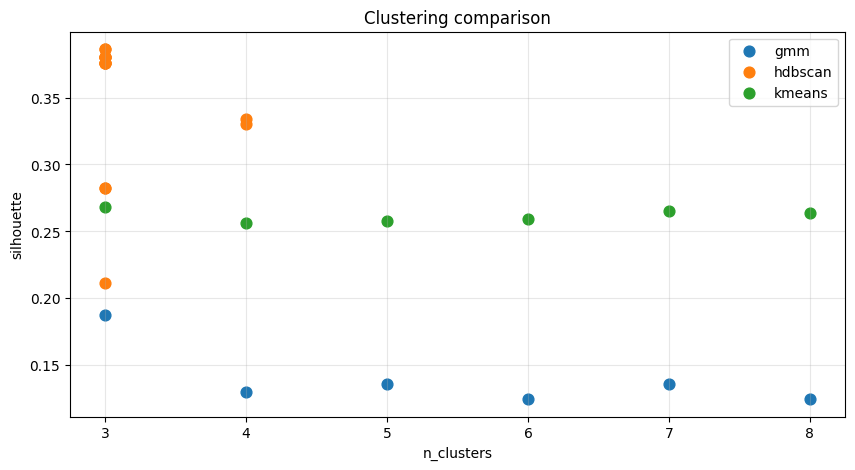

In [19]:
all_results = pd.concat(
    [
        kmeans_results_df,
        gmm_results_df,
        hdbscan_results_df if len(hdbscan_results_df) else pd.DataFrame(),
    ],
    ignore_index=True,
    sort=False,
)

# Davies-Bouldin: РјРµРЅСЊС€Рµ Р»СѓС‡С€Рµ.
# Silhouette/Calinski: Р±РѕР»СЊС€Рµ Р»СѓС‡С€Рµ.
display(
    all_results
    .sort_values(["silhouette", "noise_ratio"], ascending=[False, True])
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
for method, part in all_results.groupby("method"):
    plt.scatter(part["n_clusters"], part["silhouette"], label=method, s=60)

plt.xlabel("n_clusters")
plt.ylabel("silhouette")
plt.title("Clustering comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 17. Р’С‹Р±РёСЂР°РµРј РјРѕРґРµР»Рё РґР»СЏ РґРµС‚Р°Р»СЊРЅРѕРіРѕ СЃСЂР°РІРЅРµРЅРёСЏ

РќР°СЃС‚СЂРѕР№РєРё РЅРёР¶Рµ РјРѕР¶РЅРѕ РїРѕРјРµРЅСЏС‚СЊ РїРѕСЃР»Рµ РїСЂРѕСЃРјРѕС‚СЂР° С‚Р°Р±Р»РёС†С‹ `all_results`.

РџРѕ СѓРјРѕР»С‡Р°РЅРёСЋ:
- KMeans: k=4
- GMM: k=4
- HDBSCAN: РїРµСЂРІР°СЏ РєРѕРЅС„РёРіСѓСЂР°С†РёСЏ, РєРѕС‚РѕСЂР°СЏ РґР°Р»Р° 3+ non-noise РєР»Р°СЃС‚РµСЂР° Рё СЂР°Р·СѓРјРЅС‹Р№ noise_ratio

In [20]:
# --- KMeans selected ---
KMEANS_K = 4
kmeans_selected = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init="auto")
cluster_df["label_kmeans"] = kmeans_selected.fit_predict(X)

# --- GMM selected ---
GMM_K = 4
gmm_selected = GaussianMixture(
    n_components=GMM_K,
    covariance_type="full",
    random_state=RANDOM_STATE,
    reg_covar=1e-6,
)
cluster_df["label_gmm"] = gmm_selected.fit_predict(X)

# --- HDBSCAN selected ---
if hdbscan is not None and len(hdbscan_results_df):
    candidate_hdb = (
        hdbscan_results_df
        .query("n_clusters >= 3 and noise_ratio < 0.60")
        .sort_values(["silhouette", "noise_ratio"], ascending=[False, True])
    )

    if len(candidate_hdb):
        best_params = candidate_hdb.iloc[0]["params"]
    else:
        best_params = hdbscan_results_df.sort_values(["n_clusters", "noise_ratio"], ascending=[False, True]).iloc[0]["params"]

    print("Selected HDBSCAN:", best_params)

    parts = best_params.replace("min_cluster_size=", "").replace(" min_samples=", "").split(",")
    selected_mcs = int(parts[0])
    selected_ms = int(parts[1].strip())

    hdbscan_selected = hdbscan.HDBSCAN(
        min_cluster_size=selected_mcs,
        min_samples=selected_ms,
        metric="euclidean",
        cluster_selection_method="eom",
    )

    cluster_df["label_hdbscan"] = hdbscan_selected.fit_predict(X)
else:
    cluster_df["label_hdbscan"] = np.nan

cluster_df[["label_kmeans", "label_gmm", "label_hdbscan"]].head()

Selected HDBSCAN: min_cluster_size=1000, min_samples=30


,label_kmeans,label_gmm,label_hdbscan
19,0,3,-1
20,0,3,-1
21,0,3,-1
22,0,3,-1
23,0,3,-1


## 18. Р”Р°С‘Рј РєР»Р°СЃС‚РµСЂР°Рј РїРѕРЅСЏС‚РЅС‹Рµ РёРјРµРЅР° РїРѕ СЂР°РЅРіСѓ hardness

In [21]:
cluster_df = add_energy_type_names(cluster_df, "label_kmeans", "energy_type_kmeans")
cluster_df = add_energy_type_names(cluster_df, "label_gmm", "energy_type_gmm")

if cluster_df["label_hdbscan"].notna().any():
    cluster_df = add_energy_type_names(cluster_df, "label_hdbscan", "energy_type_hdbscan")
else:
    cluster_df["energy_type_hdbscan"] = np.nan

## 19. РЎРІРѕРґРєРё РїРѕ РјРµС‚РѕРґР°Рј

In [22]:
print("KMeans summary")
display(summarize_clusters(cluster_df, "energy_type_kmeans"))

print("GMM summary")
display(summarize_clusters(cluster_df, "energy_type_gmm"))

if cluster_df["label_hdbscan"].notna().any():
    print("HDBSCAN summary")
    display(summarize_clusters(cluster_df, "energy_type_hdbscan"))

KMeans summary


,rows,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,relative_residual_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median
energy_type_kmeans,,,,,,,,,,,,
soft_low_energy,63771,0.01818,-2.787863,7.061702e+07,1.416108e-08,0.005220,0.389393,0.006001,2.529641,16981.0,13993.0,103.458
medium_low_energy,88024,0.01212,-0.122570,1.125170e+08,8.889523e-09,-0.000735,-0.059403,0.005295,16.192260,17673.0,14167.0,104.154
medium_high_energy,136858,0.01212,0.198149,1.256152e+08,7.960997e-09,-0.000711,-0.055588,0.004471,1.057329,20413.0,15807.0,102.564
hard_high_energy,93982,0.00606,2.046030,1.906965e+08,5.251009e-09,-0.003809,-0.333075,0.003685,1.991193,19097.0,14168.0,103.410


GMM summary


,rows,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,relative_residual_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median
energy_type_gmm,,,,,,,,,,,,
soft_low_energy,60407,0.01818,-2.839351,6.867799e+07,1.456144e-08,0.004789,0.365787,0.005972,4.669389,15576.0,12530.0,103.458
medium_low_energy,127795,0.01515,-0.684075,1.036290e+08,9.651073e-09,0.001085,0.077548,0.005047,2.399202,19136.0,15227.0,103.158
medium_high_energy,78440,0.01212,0.644809,1.361878e+08,7.342980e-09,-0.001546,-0.115872,0.004287,1.002613,20701.0,15865.0,102.522
hard_high_energy,115993,0.00909,1.834501,1.768685e+08,5.657746e-09,-0.003330,-0.297277,0.003904,5.556812,19298.0,14327.0,103.602


HDBSCAN summary


,rows,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,relative_residual_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median
energy_type_hdbscan,,,,,,,,,,,,
noise_transition,228699,0.01212,-0.142585,1.081365e+08,9.251050e-09,-0.000885,-0.074811,0.005150,2.828837,17348.0,13778.0,103.308
soft_low_energy,45034,0.01212,0.400793,1.374248e+08,7.279497e-09,-0.000638,-0.048555,0.004283,17.045119,20850.5,15793.0,104.598
medium_energy,95808,0.01212,0.401016,1.317698e+08,7.588446e-09,-0.000964,-0.074410,0.004277,0.982252,20796.0,16043.0,102.522
hard_high_energy,13094,0.00606,2.391974,2.272989e+08,4.398768e-09,-0.003358,-0.337642,0.003223,0.860141,20385.0,14214.5,103.008


## 20. РџСЂРѕРІРµСЂРєР°: РЅРµ РІС‹РґРµР»РёР»Рё Р»Рё РјС‹ РїСЂРѕСЃС‚Рѕ СѓРїСЂР°РІР»РµРЅРёРµ?

РЎСЂР°РІРЅРёРІР°РµРј pressure-РјРµРґРёР°РЅС‹ РїРѕ РєР»Р°СЃСЃР°Рј.  
Р•СЃР»Рё РєР»Р°СЃС‚РµСЂС‹ СЂР°Р·Р»РёС‡Р°СЋС‚СЃСЏ С‚РѕР»СЊРєРѕ РґР°РІР»РµРЅРёСЏРјРё, Р° РЅРµ `pseudo_mse/residual/efficiency`, Р·РЅР°С‡РёС‚ РѕРЅРё РІСЃС‘ РµС‰С‘ РѕС‚СЂР°Р¶Р°СЋС‚ operator policy.

In [23]:
def control_leakage_check(data, type_col):
    return (
        data
        .groupby(type_col)
        .agg(
            rows=("speed", "size"),
            pressure_axis_median=("pressure_axis", "median"),
            pressure_axis_q25=("pressure_axis", lambda s: s.quantile(0.25)),
            pressure_axis_q75=("pressure_axis", lambda s: s.quantile(0.75)),
            pressure_rotation_median=("pressure_rotation", "median"),
            pressure_rotation_q25=("pressure_rotation", lambda s: s.quantile(0.25)),
            pressure_rotation_q75=("pressure_rotation", lambda s: s.quantile(0.75)),
            speed_median=("speed", "median"),
            hardness_score_median=("hardness_score", "median"),
            pseudo_mse_smooth=("pseudo_mse_roll_median_60", "median"),
            efficiency_smooth=("drilling_efficiency_roll_median_60", "median"),
            residual_smooth=("formation_residual_roll_median_60", "median"),
        )
        .sort_values("hardness_score_median")
    )

print("KMeans leakage check")
display(control_leakage_check(cluster_df, "energy_type_kmeans"))

print("GMM leakage check")
display(control_leakage_check(cluster_df, "energy_type_gmm"))

if cluster_df["energy_type_hdbscan"].notna().any():
    print("HDBSCAN leakage check")
    display(control_leakage_check(cluster_df, "energy_type_hdbscan"))

KMeans leakage check


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth
energy_type_kmeans,,,,,,,,,,,,
soft_low_energy,63771,16981.0,13789.0,19700.0,13993.0,11022.0,16126.00,0.01818,-2.787863,7.061702e+07,1.416108e-08,0.005220
medium_low_energy,88024,17673.0,14713.0,20539.0,14167.0,11255.0,16105.25,0.01212,-0.122570,1.125170e+08,8.889523e-09,-0.000735
medium_high_energy,136858,20413.0,18719.0,21374.0,15807.0,14436.0,17124.00,0.01212,0.198149,1.256152e+08,7.960997e-09,-0.000711
hard_high_energy,93982,19097.0,16818.0,20795.0,14168.0,12333.0,15861.00,0.00606,2.046030,1.906965e+08,5.251009e-09,-0.003809


GMM leakage check


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth
energy_type_gmm,,,,,,,,,,,,
soft_low_energy,60407,15576.0,11933.00,18047.0,12530.0,10044.0,15280.0,0.01818,-2.839351,6.867799e+07,1.456144e-08,0.004789
medium_low_energy,127795,19136.0,16642.00,20797.0,15227.0,13072.0,16742.0,0.01515,-0.684075,1.036290e+08,9.651073e-09,0.001085
medium_high_energy,78440,20701.0,19589.75,21613.0,15865.0,14668.0,17127.0,0.01212,0.644809,1.361878e+08,7.342980e-09,-0.001546
hard_high_energy,115993,19298.0,16915.00,20943.0,14327.0,12457.0,16031.0,0.00909,1.834501,1.768685e+08,5.657746e-09,-0.003330


HDBSCAN leakage check


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth
energy_type_hdbscan,,,,,,,,,,,,
noise_transition,228699,17348.0,14862.00,19735.0,13778.0,11295.0,15859.0,0.01212,-0.142585,1.081365e+08,9.251050e-09,-0.000885
soft_low_energy,45034,20850.5,19735.00,21756.0,15793.0,14574.0,16941.0,0.01212,0.400793,1.374248e+08,7.279497e-09,-0.000638
medium_energy,95808,20796.0,19906.75,21601.0,16043.0,14899.0,17223.0,0.01212,0.401016,1.317698e+08,7.588446e-09,-0.000964
hard_high_energy,13094,20385.0,18870.25,21440.0,14214.5,13110.0,15430.0,0.00606,2.391974,2.272989e+08,4.398768e-09,-0.003358


## 21. PCA-РІРёР·СѓР°Р»РёР·Р°С†РёСЏ С‚СЂС‘С… РјРµС‚РѕРґРѕРІ

Explained variance ratio: [0.606959   0.18068876]


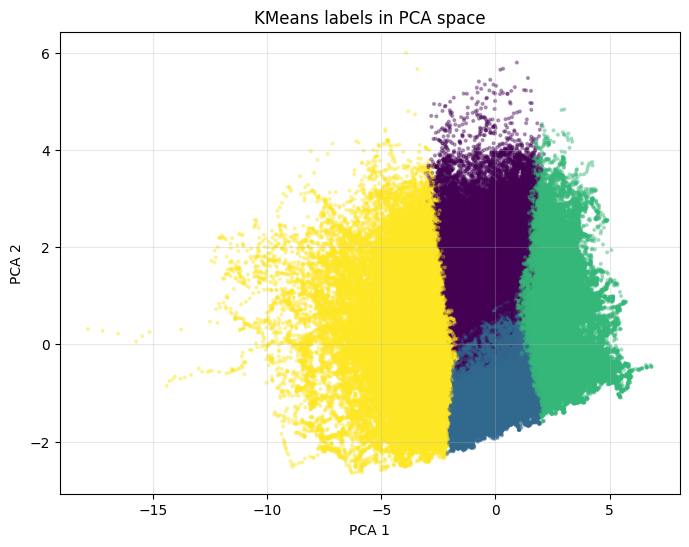

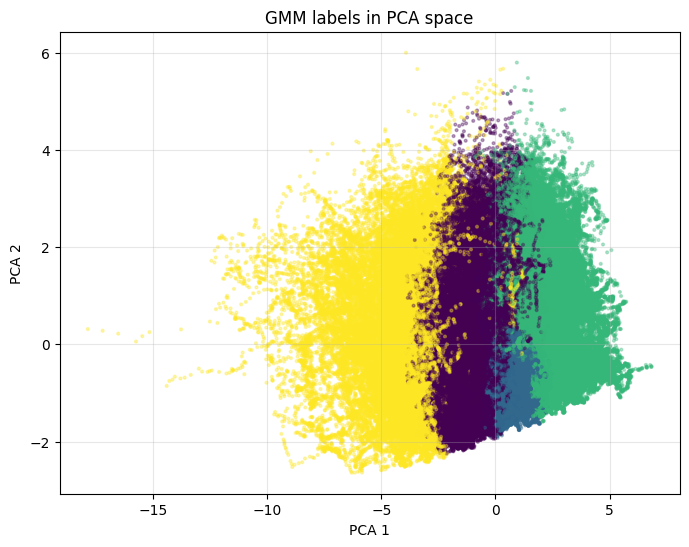

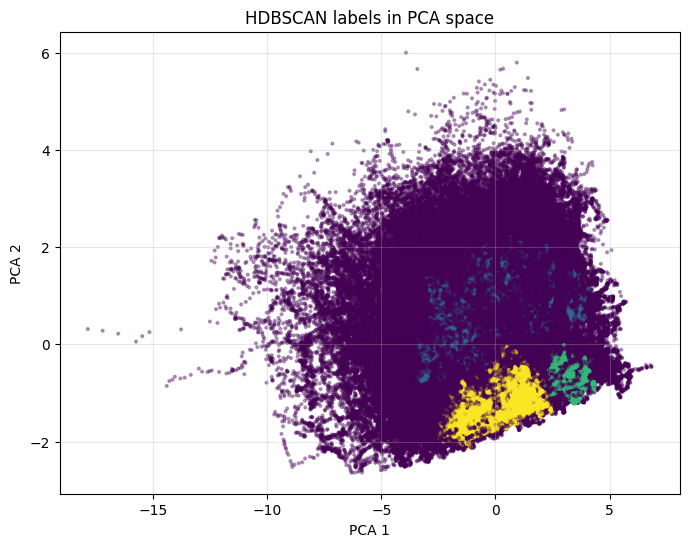

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

cluster_df["pca_1"] = X_pca[:, 0]
cluster_df["pca_2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

for label_col, title in [
    ("label_kmeans", "KMeans"),
    ("label_gmm", "GMM"),
    ("label_hdbscan", "HDBSCAN"),
]:
    if cluster_df[label_col].isna().all():
        continue

    plt.figure(figsize=(8, 6))
    plt.scatter(
        cluster_df["pca_1"],
        cluster_df["pca_2"],
        c=cluster_df[label_col],
        s=4,
        alpha=0.35,
    )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"{title} labels in PCA space")
    plt.grid(True, alpha=0.3)
    plt.show()

## 22. Р’СЂРµРјРµРЅРЅР°СЏ РІРёР·СѓР°Р»РёР·Р°С†РёСЏ РїРѕ РѕРґРЅРѕРјСѓ well_id

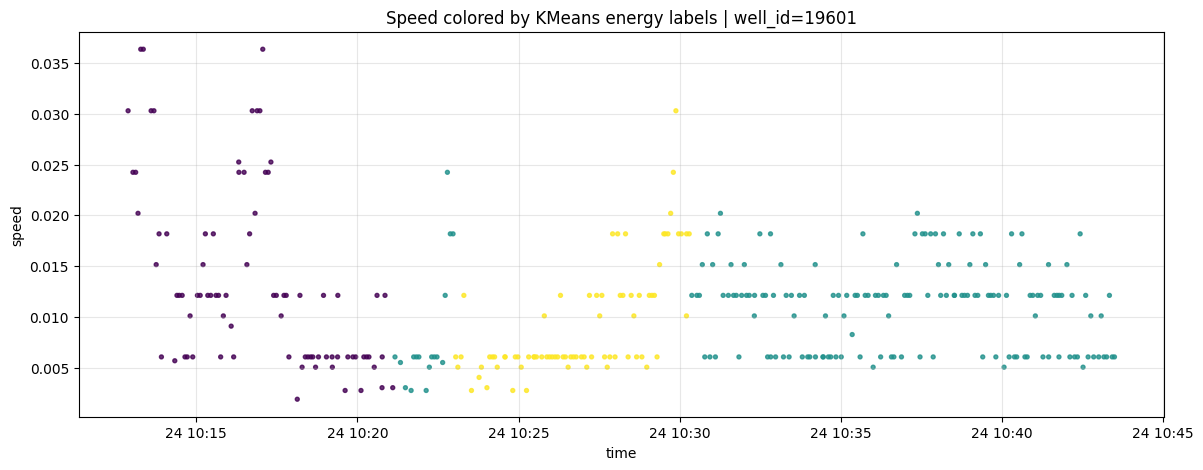

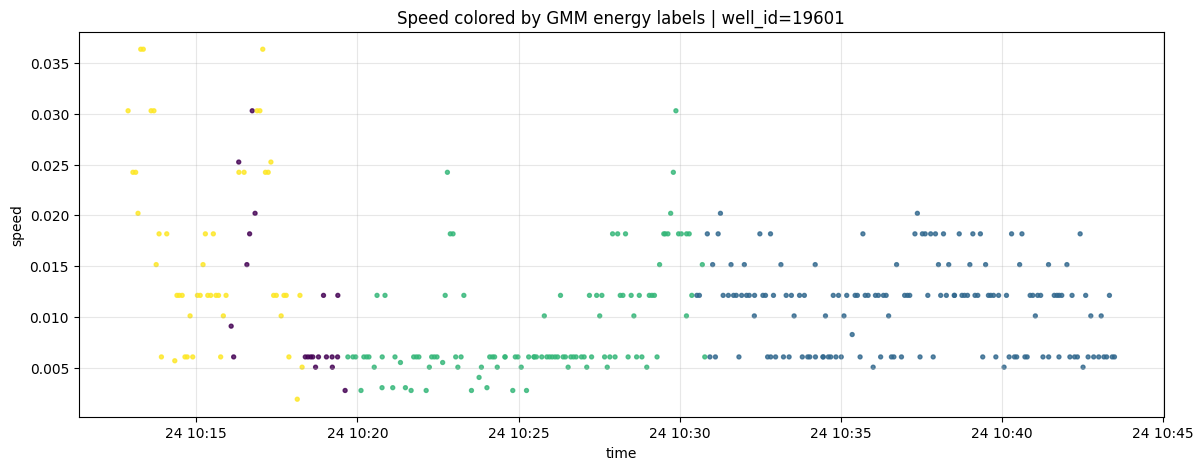

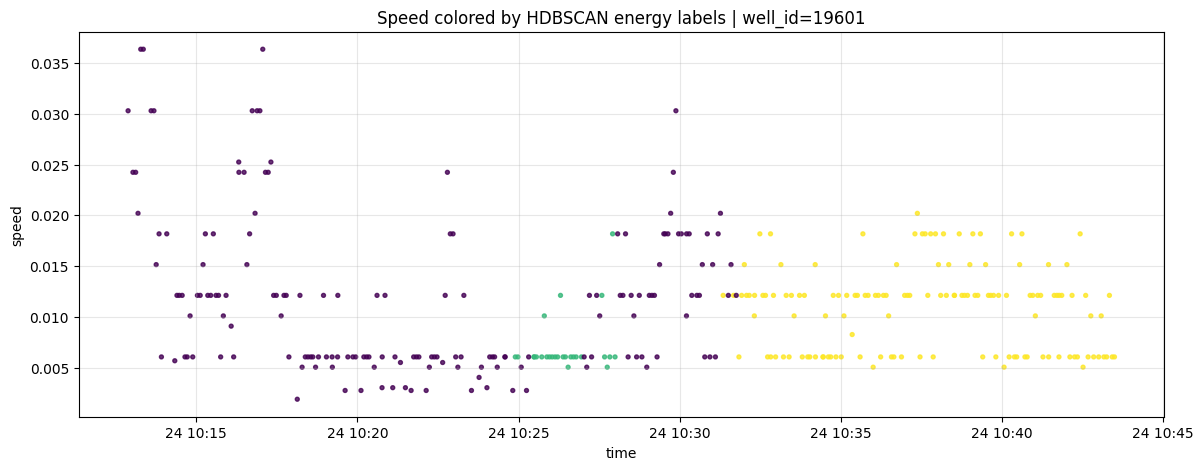

In [25]:
sample_well = cluster_df["well_id"].dropna().unique()[0]
tmp = cluster_df[cluster_df["well_id"] == sample_well].copy()

for label_col, title in [
    ("label_kmeans", "KMeans"),
    ("label_gmm", "GMM"),
    ("label_hdbscan", "HDBSCAN"),
]:
    if tmp[label_col].isna().all():
        continue

    plt.figure(figsize=(14, 5))
    plt.scatter(
        tmp["processing_time"],
        tmp["speed"],
        c=tmp[label_col],
        s=8,
        alpha=0.8,
    )
    plt.title(f"Speed colored by {title} energy labels | well_id={sample_well}")
    plt.xlabel("time")
    plt.ylabel("speed")
    plt.grid(True, alpha=0.3)
    plt.show()

## 23. Р’С‹Р±РѕСЂ С„РёРЅР°Р»СЊРЅРѕРіРѕ РјРµС‚РѕРґР°

Р РµРєРѕРјРµРЅРґР°С†РёСЏ:

- Р•СЃР»Рё HDBSCAN РґР°С‘С‚ 3вЂ“6 РєР»Р°СЃС‚РµСЂРѕРІ Рё СѓРјРµСЂРµРЅРЅС‹Р№ noise_ratio, С‡Р°С‰Рµ Р»СѓС‡С€Рµ Р±СЂР°С‚СЊ РµРіРѕ.
- Р•СЃР»Рё HDBSCAN РґР°С‘С‚ СЃР»РёС€РєРѕРј РјРЅРѕРіРѕ noise РёР»Рё 1вЂ“2 РєР»Р°СЃС‚РµСЂР°, Р±РµСЂРёС‚Рµ GMM.
- KMeans вЂ” С…РѕСЂРѕС€РёР№ baseline, РЅРѕ С‡Р°С‰Рµ С…СѓР¶Рµ РґР»СЏ continuous geology.

Р—Р°РґР°Р№С‚Рµ `FINAL_METHOD` РІСЂСѓС‡РЅСѓСЋ:
- `"hdbscan"`
- `"gmm"`
- `"kmeans"`

In [ ]:
FINAL_METHOD = "hdbscan"  # РїРѕРјРµРЅСЏР№С‚Рµ РЅР° "gmm" РёР»Рё "kmeans", РµСЃР»Рё РЅСѓР¶РЅРѕ

if FINAL_METHOD == "hdbscan" and cluster_df["label_hdbscan"].notna().any():
    final_label_col = "label_hdbscan"
    final_type_col = "energy_type_hdbscan"
elif FINAL_METHOD == "gmm":
    final_label_col = "label_gmm"
    final_type_col = "energy_type_gmm"
else:
    final_label_col = "label_kmeans"
    final_type_col = "energy_type_kmeans"

print("Final method:", FINAL_METHOD)
print("Final label col:", final_label_col)
print("Final type col:", final_type_col)

display(summarize_clusters(cluster_df, final_type_col))

Final method: hdbscan
Final label col: label_hdbscan
Final type col: energy_type_hdbscan


,rows,speed_median,hardness_score_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,relative_residual_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median
energy_type_hdbscan,,,,,,,,,,,,
noise_transition,228699,0.01212,-0.142585,1.081365e+08,9.251050e-09,-0.000885,-0.074811,0.005150,2.828837,17348.0,13778.0,103.308
soft_low_energy,45034,0.01212,0.400793,1.374248e+08,7.279497e-09,-0.000638,-0.048555,0.004283,17.045119,20850.5,15793.0,104.598
medium_energy,95808,0.01212,0.401016,1.317698e+08,7.588446e-09,-0.000964,-0.074410,0.004277,0.982252,20796.0,16043.0,102.522
hard_high_energy,13094,0.00606,2.391974,2.272989e+08,4.398768e-09,-0.003358,-0.337642,0.003223,0.860141,20385.0,14214.5,103.008


## 24. Р’РѕР·РІСЂР°С‰Р°РµРј labels РІ РѕСЃРЅРѕРІРЅРѕР№ РґР°С‚Р°СЃРµС‚

In [30]:
cols_to_merge = [
    "processing_time",
    "well_id",
    "label_kmeans",
    "energy_type_kmeans",
    "label_gmm",
    "energy_type_gmm",
    "label_hdbscan",
    "energy_type_hdbscan",
]

df_out = df.merge(
    cluster_df[cols_to_merge],
    on=["processing_time", "well_id"],
    how="left",
)

df_out["rock_energy_label_final"] = df_out[final_label_col]
df_out["rock_energy_type_final"] = df_out[final_type_col]

print(df_out.shape)

df_out[[
    "processing_time",
    "well_id",
    "speed",
    "expected_speed_from_controls",
    "formation_residual",
    "pseudo_mse",
    "hardness_score",
    "rock_energy_label_final",
    "rock_energy_type_final",
]].head()

## 25. РЎРѕС…СЂР°РЅРµРЅРёРµ СЂРµР·СѓР»СЊС‚Р°С‚Р°

In [31]:
OUTPUT_PATH = f"united_with_rock_energy_classes_{FINAL_METHOD}.csv"

df_out.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

## 26. РљР°Рє С‡РёС‚Р°С‚СЊ СЂРµР·СѓР»СЊС‚Р°С‚

- `hardness_score` вЂ” РЅРµРїСЂРµСЂС‹РІРЅС‹Р№ РёРЅРґРµРєСЃ СЌРЅРµСЂРіРѕС‘РјРєРѕСЃС‚Рё.
- `rock_energy_type_final` вЂ” РґРёСЃРєСЂРµС‚РЅС‹Р№ РєР»Р°СЃСЃ, РІС‹Р±СЂР°РЅРЅС‹Р№ С„РёРЅР°Р»СЊРЅС‹Рј РјРµС‚РѕРґРѕРј.
- `noise_transition` Сѓ HDBSCAN вЂ” РїРµСЂРµС…РѕРґРЅС‹Рµ/РЅРµСѓСЃС‚РѕР№С‡РёРІС‹Рµ РёРЅС‚РµСЂРІР°Р»С‹, РєРѕС‚РѕСЂС‹Рµ Р»СѓС‡С€Рµ РЅРµ РёСЃРїРѕР»СЊР·РѕРІР°С‚СЊ РґР»СЏ РѕР±СѓС‡РµРЅРёСЏ РѕРїС‚РёРјРёР·Р°С‚РѕСЂР° РєР°Рє РѕС‚РґРµР»СЊРЅСѓСЋ СЃС‚Р°Р±РёР»СЊРЅСѓСЋ РїРѕСЂРѕРґСѓ.
- Р•СЃР»Рё РєР»Р°СЃСЃС‹ СЃРёР»СЊРЅРѕ РѕС‚Р»РёС‡Р°СЋС‚СЃСЏ С‚РѕР»СЊРєРѕ РїРѕ `pressure_axis`/`pressure_rotation`, Р·РЅР°С‡РёС‚ РІС‹РґРµР»СЏРµС‚СЃСЏ РїРѕР»РёС‚РёРєР° РѕРїРµСЂР°С‚РѕСЂР°, Р° РЅРµ РїРѕСЂРѕРґР°.